# Albedo demo

Albedo flips plots between dark and light backgrounds while **keeping their hues**: blue stays blue, orange stays orange. Use it to move a figure from a dark talk slide into a light paper, or the other way round, without re-plotting.

A plain colour invert turns blue into orange and yellow into blue. Albedo inverts, then rotates the hue back by 180°, so only lightness flips. The default `"css"` mode is the same maths as the CSS filter `invert(1) hue-rotate(180deg)`.

This notebook covers:

1. Quick start: flip a matplotlib figure
2. Side-by-side comparisons
3. Light → dark, for talk slides
4. The two modes, `css` and `oklab`
5. Options: `hue`, `black`, `white`
6. What gets recoloured (a stress-test figure)
7. Saving, including vector PDF output
8. Images, arrays and files
9. Single colours and palettes
10. Batch processing and the command line
11. Tips and limitations

**Install** (once): `pip install -e ~/repos/albedo[all]`

In [1]:
import io
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image

import albedo

%config InlineBackend.figure_format = "png"
mpl.rcParams["figure.dpi"] = 90

OUT = Path("demo_outputs")
OUT.mkdir(exist_ok=True)
rng = np.random.default_rng(42)
print("albedo", albedo.__version__, "| matplotlib", mpl.__version__)

albedo 0.3.0 | matplotlib 3.10.9


### Some astrophysics-flavoured data

A toy matter power spectrum for three values of $\Omega_m$, and a lognormal "density field" to use as an image.

In [2]:
k = np.logspace(-2.5, 0.5, 300)                    # h/Mpc

def toy_pk(k, om):
    keq = 0.073 * om                              # turnover scale
    return 2e4 * (k / keq) / (1 + (k / keq) ** 2.6) * (1 + 0.05 * np.sin(k / 0.06))

omegas = [0.25, 0.30, 0.35]

# lognormal density field with a red-ish power spectrum
n = 128
kx = np.fft.fftfreq(n)[:, None]; ky = np.fft.fftfreq(n)[None, :]
kk = np.hypot(kx, ky); kk[0, 0] = 1
field = np.real(np.fft.ifft2(np.fft.fft2(rng.normal(size=(n, n))) * kk ** -1.4))
delta = np.exp(field / field.std()) - 1           # overdensity

## 1. Quick start

Make a figure the way you normally would, then call `albedo.flip_figure`. It returns a **new, recoloured copy**; your original figure is not touched.

Here the original uses matplotlib's `dark_background` style, as you might for a talk.

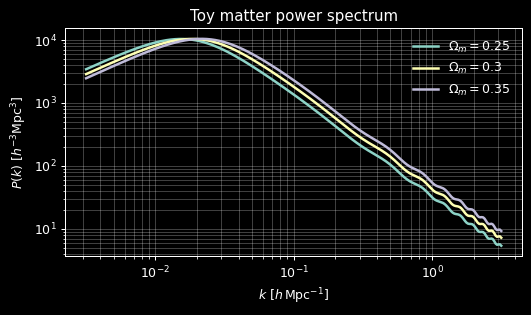

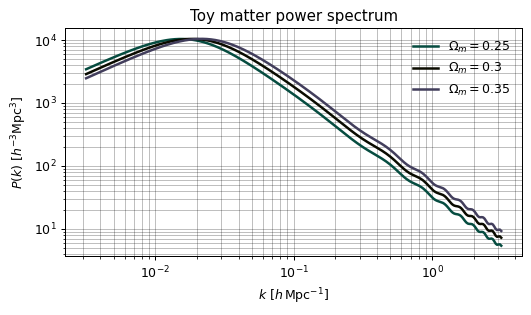

In [3]:
def spectrum_figure():
    fig, ax = plt.subplots(figsize=(6, 3.6))
    for om in omegas:
        ax.loglog(k, toy_pk(k, om), lw=2, label=rf"$\Omega_m = {om}$")
    ax.set(xlabel=r"$k\ [h\,\mathrm{Mpc}^{-1}]$", ylabel=r"$P(k)\ [h^{-3}\mathrm{Mpc}^3]$",
           title="Toy matter power spectrum")
    ax.grid(alpha=0.25, which="both")
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig

with plt.style.context("dark_background"):
    fig = spectrum_figure()

light = albedo.flip_figure(fig)   # the original `fig` is unchanged

Both figures appear above: the original, then the flipped copy. Line colours keep their hue; only light and dark swap.

`flip_figure` recolours the figure's own elements (lines, text, patches, colormaps and so on) instead of taking a screenshot, so the result is still an ordinary matplotlib figure. You can keep editing it:

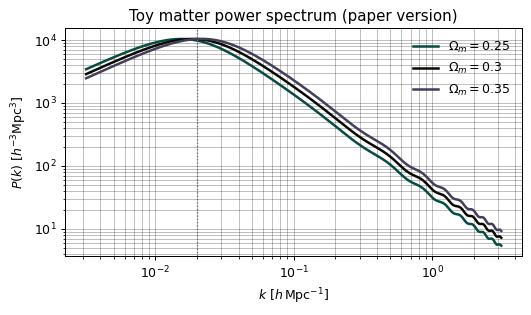

In [4]:
ax = light.axes[0]
ax.set_title("Toy matter power spectrum (paper version)")
ax.axvline(0.02, color="0.4", ls=":", lw=1)
light

## 2. Side by side with `compare`

`albedo.compare(fig)` renders the original and the flipped version next to each other in a single figure, which is handy for checking a result at a glance. It returns the comparison figure.

(`plt.close(fig)` stops the notebook from also showing the original on its own.)

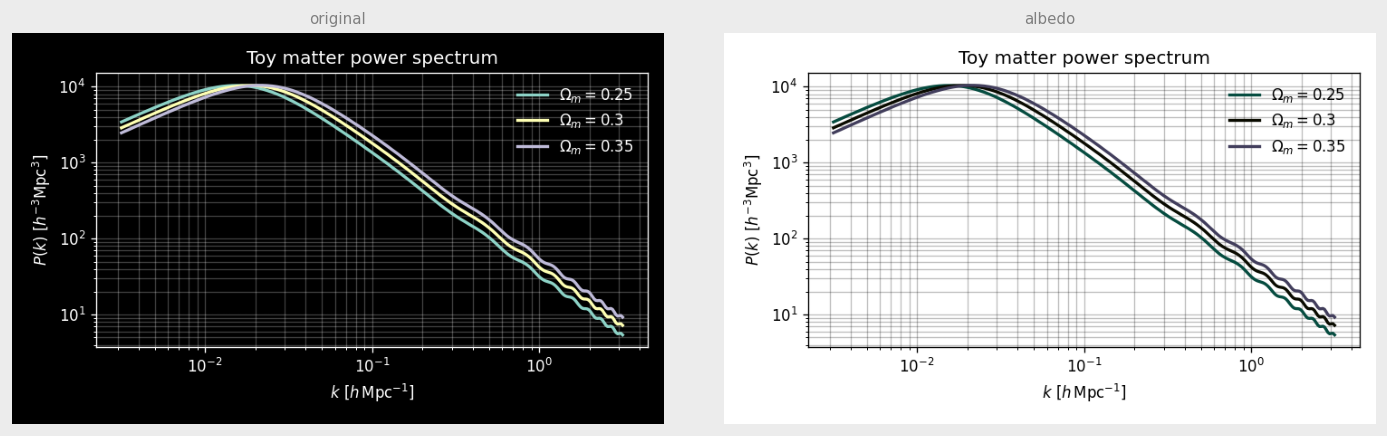

In [5]:
with plt.style.context("dark_background"):
    fig = spectrum_figure()
plt.close(fig)
albedo.compare(fig);

## 3. Light → dark, for talk slides

The flip works in both directions. Here's a default (light) matplotlib figure with an image, a colorbar and a contour overlay, turned into a dark version for slides.

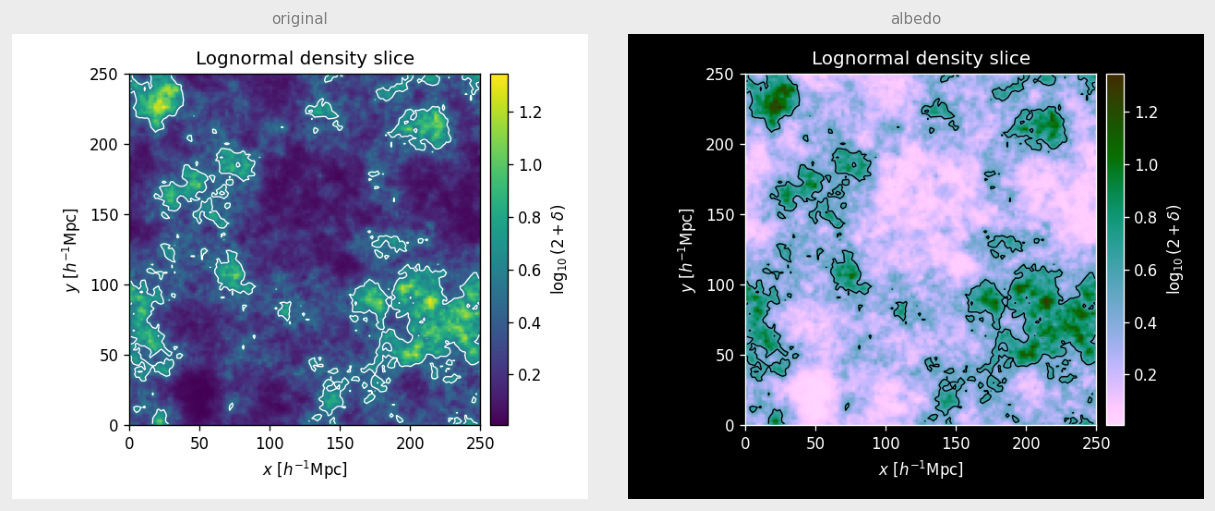

In [6]:
def density_figure():
    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    im = ax.imshow(np.log10(2 + delta), cmap="viridis", origin="lower", extent=[0, 250, 0, 250])
    ax.contour(np.log10(2 + delta), levels=[0.55], colors="white", linewidths=0.8,
               origin="lower", extent=[0, 250, 0, 250])
    cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cb.set_label(r"$\log_{10}(2 + \delta)$")
    ax.set(xlabel=r"$x\ [h^{-1}\mathrm{Mpc}]$", ylabel=r"$y\ [h^{-1}\mathrm{Mpc}]$",
           title="Lognormal density slice")
    fig.tight_layout()
    return fig

fig = density_figure()
plt.close(fig)
albedo.compare(fig);

Notice the colormap: viridis goes from dark purple to bright yellow, so after a lightness flip it runs from **light** lilac to **dark** green. The mapping between colour and value is still monotonic in lightness, and the colorbar is flipped along with the image, so the figure still reads correctly.

If you'd rather keep a named colormap exactly as it is, re-apply it after flipping (see the tips at the end).

## 4. Modes: `css` and `oklab`

| Mode | What it does | Use it when |
|---|---|---|
| `"css"` (default) | Exactly the browser filter `invert(1) hue-rotate(180deg)` | You want figures to match slides or web pages that use that filter |
| `"oklab"` | Flips *perceived* lightness in the OKLab colour space, keeping hue and chroma exactly | You care about colour fidelity more than matching the CSS filter |

The difference is easiest to see on colormaps. Each row below shows a colormap, then its `css` flip, then its `oklab` flip.

In [7]:
cmaps = ["viridis", "magma", "RdBu_r", "coolwarm", "twilight", "tab10"]
grad = np.linspace(0, 1, 256)

fig, axes = plt.subplots(len(cmaps), 3, figsize=(8, 0.55 * len(cmaps) + 0.6))
for row, name in zip(axes, cmaps):
    rgba = mpl.colormaps[name](grad)[None, :, :]          # shape (1, 256, 4)
    strips = [rgba,
              albedo.flip_image(rgba, mode="css"),
              albedo.flip_image(rgba, mode="oklab")]
    for ax, strip in zip(row, strips):
        ax.imshow(strip, aspect="auto")
        ax.set_xticks([]); ax.set_yticks([])
    row[0].set_ylabel(name, rotation=0, ha="right", va="center", fontsize=9)
for ax, t in zip(axes[0], ["original", 'mode="css"', 'mode="oklab"']):
    ax.set_title(t, fontsize=10)
fig.tight_layout(h_pad=0.3)

Diverging maps like `RdBu_r` and `coolwarm` survive very well: the midpoint was light and becomes dark, and the two arms keep their hues. `oklab` keeps saturation a little more faithfully; `css` gives slightly brighter mid-tones.

Greys map differently too. `css` flips pixel values (50% grey stays 50% grey), while `oklab` flips how bright a grey *looks*:

In [8]:
greys = np.linspace(0, 1, 5)[:, None].repeat(3, 1)
print(" input   css    oklab")
for g, c, o in zip(greys, albedo.flip_rgb(greys, mode="css"), albedo.flip_rgb(greys, mode="oklab")):
    print(f"{g[0]:6.2f} {c[0]:6.2f} {o[0]:6.2f}")

 input   css    oklab
  0.00   1.00   1.00
  0.25   0.75   0.54
  0.50   0.50   0.28
  0.75   0.25   0.08
  1.00   0.00   0.00


## 5. Options: `hue`, `black`, `white`

Every Albedo function takes the same keyword options:

| Option | Default | Meaning |
|---|---|---|
| `mode` | `"css"` | `"css"` or `"oklab"` |
| `hue` | `0` | extra hue rotation in degrees after the flip; `0` keeps every hue |
| `black` | `"#000000"` | the darkest output colour |
| `white` | `"#ffffff"` | the lightest output colour |

`black` and `white` set the output range. The most useful case is matching a slide background exactly, so the figure blends in with no visible rectangle. Say your dark slides use `#0c0d12`:

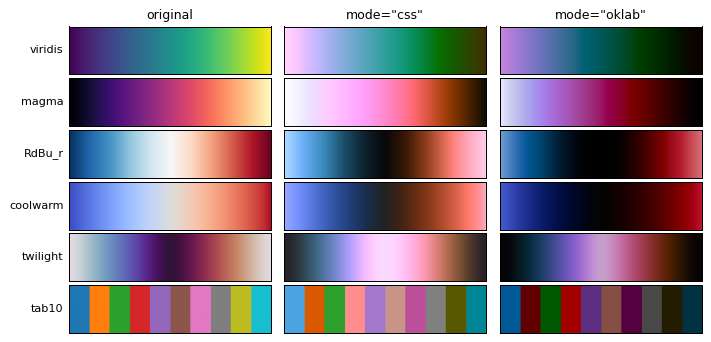

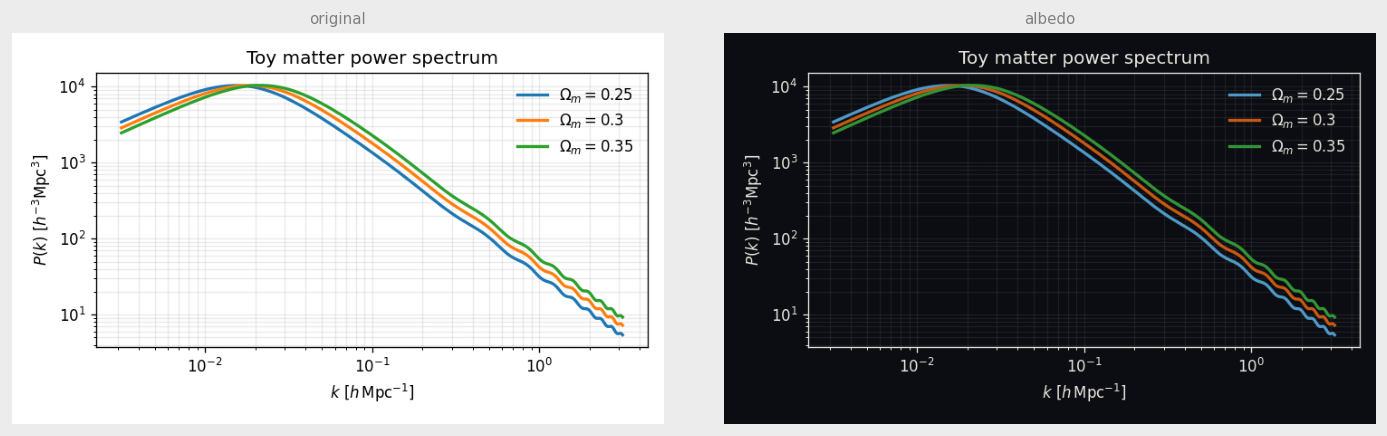

In [9]:
SLIDE_BG = "#0c0d12"

fig = spectrum_figure()                  # a light figure this time
plt.close(fig)
albedo.compare(fig, black=SLIDE_BG, white="#e8e6df");

`hue` rotates every colour after the flip. It's mainly for fine-tuning, for example nudging a palette so it sits better next to a slide's accent colour:

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(11, 2.6))
with plt.style.context("dark_background"):
    src = spectrum_figure()
plt.close(src)

buf = io.BytesIO(); src.savefig(buf, format="png", dpi=60); buf.seek(0)
img = np.asarray(Image.open(buf))
for ax, h in zip(axes, [-40, 0, 40, 90]):
    ax.imshow(albedo.flip_image(img, hue=h))
    ax.set_title(f"hue={h}°", fontsize=10); ax.set_axis_off()
fig.tight_layout()

## 6. What gets recoloured

`flip_figure` walks every element of the figure and recolours:

- lines and markers (including marker faces and edges set separately)
- text, titles, labels, tick labels, legends and text boxes
- patches: bars, histograms, `fill_between`, arrows, spines, backgrounds
- collections: scatter, error bars, `LineCollection`, `PolyCollection`, contours
- colour-mapped artists (`imshow`, `pcolormesh`, scatter with `c=`, `contourf`) via a flipped colormap, **and their colorbars**
- RGB(A) images drawn with `imshow`

Here's a figure that uses most of these at once.

In [11]:
def kitchen_sink():
    fig = plt.figure(figsize=(11, 6.5))
    gs = fig.add_gridspec(2, 3)

    # lines, markers, error bars, fill, annotation with arrow, text box
    ax = fig.add_subplot(gs[0, 0])
    x = np.linspace(0, 10, 60)
    ax.plot(x, np.sin(x), lw=2, label="model")
    ax.errorbar(x[::5], np.sin(x[::5]) + rng.normal(0, .15, 12), yerr=.15, fmt="o",
                mfc="none", capsize=2, label="data")
    ax.fill_between(x, np.sin(x) - .3, np.sin(x) + .3, alpha=.25, color="C0", lw=0)
    ax.annotate("peak", xy=(np.pi / 2, 1), xytext=(3.5, 1.35),
                arrowprops=dict(arrowstyle="->", color="C3"), color="C3")
    ax.text(6.5, -1.3, r"$\chi^2_\nu = 1.03$", bbox=dict(boxstyle="round", fc="C2", alpha=.35, ec="C2"))
    ax.set_ylim(-1.7, 1.7); ax.legend(loc="upper right", fontsize=8); ax.set_title("lines & errors")

    # histogram with step outline
    ax = fig.add_subplot(gs[0, 1])
    for i, mu in enumerate([0, 1.5]):
        s = rng.normal(mu, 1, 3000)
        ax.hist(s, bins=40, alpha=.6, color=f"C{i}")
        ax.hist(s, bins=40, histtype="step", color=f"C{i}", lw=1.2)
    ax.set_title("histograms")

    # colour-mapped scatter with colorbar
    ax = fig.add_subplot(gs[0, 2])
    z = rng.uniform(0, 3, 400)
    sc = ax.scatter(rng.normal(size=400), rng.normal(size=400), c=z, s=12, cmap="plasma")
    fig.colorbar(sc, ax=ax, label="redshift")
    ax.set_title("scatter + colorbar")

    # pcolormesh with diverging map + colorbar
    ax = fig.add_subplot(gs[1, 0])
    X, Y = np.meshgrid(np.linspace(-2, 2, 60), np.linspace(-2, 2, 60))
    pm = ax.pcolormesh(X, Y, np.sin(2 * X) * np.cos(2 * Y), cmap="RdBu_r", shading="auto")
    fig.colorbar(pm, ax=ax)
    ax.set_title("pcolormesh")

    # filled contours + contour lines + labels
    ax = fig.add_subplot(gs[1, 1])
    Z = np.exp(-(X**2 + Y**2)) + 0.5 * np.exp(-((X - 1)**2 + (Y + 1)**2) * 3)
    cf = ax.contourf(X, Y, Z, levels=8, cmap="cividis")
    cs = ax.contour(X, Y, Z, levels=8, colors="k", linewidths=.5)
    ax.clabel(cs, fontsize=7)
    fig.colorbar(cf, ax=ax)
    ax.set_title("contourf + labels")

    # bars + an RGB image inset
    ax = fig.add_subplot(gs[1, 2])
    ax.bar(["CNN", "GNN", "MLP", "P(k)"], [0.021, 0.018, 0.034, 0.047],
           color=["C0", "C1", "C2", "C7"], edgecolor="k")
    ax.set_ylabel(r"$\sigma(\Omega_m)$"); ax.set_title("bars + RGB inset")
    ins = ax.inset_axes([0.05, 0.55, 0.4, 0.4])
    rgb = np.dstack([np.linspace(0, 1, 32)[None].repeat(32, 0),
                     np.linspace(0, 1, 32)[:, None].repeat(32, 1),
                     np.full((32, 32), 0.6)])
    ins.imshow(rgb); ins.set_xticks([]); ins.set_yticks([])

    fig.suptitle("Kitchen sink", fontsize=13)
    fig.tight_layout()
    return fig

fig = kitchen_sink()
plt.close(fig)
dark = albedo.flip_figure(fig)

That's the flipped copy (the original was light). Every colorbar matches its flipped image.

**How faithful is it?** A good test is to compare the vector recolouring with simply flipping a screenshot of the original pixel by pixel. They should agree almost exactly:

In [12]:
def to_array(f, dpi=80):
    buf = io.BytesIO()
    f.savefig(buf, format="png", dpi=dpi, facecolor=f.get_facecolor())
    buf.seek(0)
    return np.asarray(Image.open(buf).convert("RGB")).astype(int)

vector = to_array(dark)
pixels = albedo.flip_image(to_array(fig).astype(np.uint8)).astype(int)
diff = np.abs(vector - pixels).max(axis=-1)
print(f"median difference: {np.median(diff):.1f} / 255")
print(f"99th percentile:   {np.percentile(diff, 99):.1f} / 255   (anti-aliased edges)")

median difference: 0.0 / 255
99th percentile:   13.0 / 255   (anti-aliased edges)


## 7. Saving

Because the flipped figure is a real matplotlib figure, `savefig` works as usual and **PDF/SVG output stays vector**.

`albedo.savefig_pair` saves the original and the flipped version in one call. Any `savefig` keyword works:

In [13]:
orig_path, flipped_path = albedo.savefig_pair(fig, OUT / "kitchen_sink.pdf", bbox_inches="tight")
print(orig_path, "and", flipped_path)

# the flipped PDF contains vector paths and text, not one big picture
pdf = flipped_path.read_bytes()
print("text/vector operators present:", b"BT" in pdf or b"/Font" in pdf)

demo_outputs/kitchen_sink.pdf and demo_outputs/kitchen_sink_inverted.pdf
text/vector operators present: True


Pass flip options through `flip_opts`, and change the file suffix with `suffix`:

In [14]:
albedo.savefig_pair(spectrum_figure(), OUT / "pk.png", dpi=200,
                    suffix="_slide", flip_opts=dict(black=SLIDE_BG, mode="oklab"))
plt.close("all")
sorted(p.name for p in OUT.iterdir())

['kitchen_sink.pdf', 'kitchen_sink_inverted.pdf', 'pk.png', 'pk_slide.png']

**In place.** If you don't need the original any more, `inplace=True` recolours the figure itself instead of making a copy:

```python
albedo.flip_figure(fig, inplace=True)
```

**Style sheets.** Style sheets such as `dark_background` fix `savefig.facecolor` in `rcParams`, which would normally paint the old background behind a flipped figure. Figures returned by `flip_figure` save with their own (flipped) background automatically, so you don't need to pass `facecolor=` yourself.

## 8. Images, arrays and files

For anything that isn't a live matplotlib figure (a PNG from a colleague, a screenshot, a rendered simulation frame), use `flip_image` or `flip_file`.

`flip_image` accepts a **NumPy array** (uint8 0–255 or float 0–1; greyscale, RGB or RGBA) or a **PIL image**, and returns the same kind of object. Transparency is kept.

In [15]:
# float RGB array from a colormap
rgb_float = mpl.colormaps["inferno"](np.log10(2 + delta) / np.log10(2 + delta).max())[..., :3]
flipped_float = albedo.flip_image(rgb_float)

# uint8 RGBA with a transparent circular mask
rgba_u8 = (mpl.colormaps["inferno"](np.log10(2 + delta) / np.log10(2 + delta).max()) * 255).astype(np.uint8)
yy, xx = np.mgrid[:n, :n]
rgba_u8[..., 3] = np.where(np.hypot(xx - n / 2, yy - n / 2) < n / 2.2, 255, 0)
flipped_u8 = albedo.flip_image(rgba_u8)

# PIL image
pil = Image.fromarray(rgba_u8)
flipped_pil = albedo.flip_image(pil)

print(type(flipped_float).__name__, flipped_float.dtype, flipped_float.shape)
print(type(flipped_u8).__name__, flipped_u8.dtype, flipped_u8.shape, "alpha kept:", np.array_equal(flipped_u8[..., 3], rgba_u8[..., 3]))
print(type(flipped_pil).__name__, flipped_pil.mode, flipped_pil.size)

fig, axes = plt.subplots(1, 4, figsize=(10, 2.8))
checker = (np.indices((n, n)).sum(0) // 8 % 2)[..., None] * 0.15 + 0.5
for ax, im, t in zip(axes, [rgb_float, flipped_float, rgba_u8, flipped_u8],
                     ["float RGB", "flipped", "uint8 RGBA", "flipped (alpha kept)"]):
    ax.imshow(checker.repeat(3, -1)); ax.imshow(im)
    ax.set_title(t, fontsize=10); ax.set_axis_off()
fig.tight_layout()

ndarray float64 (128, 128, 3)
ndarray uint8 (128, 128, 4) alpha kept: True
Image RGBA (128, 128)


`flip_file` works on image files and PDFs on disk. PDF pages are rasterised at `dpi`, so the output PDF is made of images; for vector output, flip the matplotlib figure instead (section 7).

demo_outputs/density_inverted.png


demo_outputs/density_inverted.pdf
demo_outputs/density_oklab.png


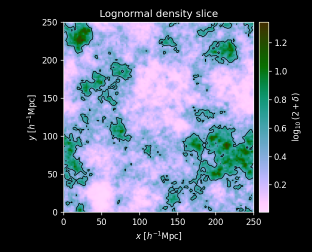

In [16]:
fig = density_figure()
fig.savefig(OUT / "density.png", dpi=120)
fig.savefig(OUT / "density.pdf")
plt.close(fig)

print(albedo.flip_file(OUT / "density.png"))                                  # -> density_inverted.png
print(albedo.flip_file(OUT / "density.pdf", dpi=200, black=SLIDE_BG))         # -> density_inverted.pdf
print(albedo.flip_file(OUT / "density.png", OUT / "density_oklab.png", mode="oklab"))

Image.open(OUT / "density_inverted.png").reduce(2)

## 9. Single colours and palettes

`flip_color` takes any matplotlib colour spec (a name, hex string, tuple, `"C3"`…) and returns an RGBA tuple. It's useful when you style something by hand and want its counterpart in the other theme.

In [17]:
for c in ["tab:blue", "tab:orange", "#e15759", "gold", "white", "0.3", (0.2, 0.6, 0.3, 0.5)]:
    print(f"{str(c):24s} -> {mpl.colors.to_hex(albedo.flip_color(c), keep_alpha=True)}")

tab:blue                 -> #4da5e2ff
tab:orange               -> #da5a00ff
#e15759                  -> #f76d6fff
gold                     -> #5e3600ff
white                    -> #000000ff
0.3                      -> #b2b2b2ff
(0.2, 0.6, 0.3, 0.5)     -> #369c5080


Flipping a whole palette, for example to build a matching `prop_cycle` for dark slides:

In [18]:
palettes = {"tab10": [f"C{i}" for i in range(10)],
            "Set2": mpl.colormaps["Set2"].colors,
            "Dark2": mpl.colormaps["Dark2"].colors}

fig, axes = plt.subplots(len(palettes), 1, figsize=(8, 2.6))
for ax, (name, cols) in zip(axes, palettes.items()):
    rows = [[mpl.colors.to_rgb(c) for c in cols],
            [albedo.flip_color(c)[:3] for c in cols]]
    ax.imshow(np.array(rows), aspect="auto")
    ax.set_yticks([0, 1], ["original", "flipped"], fontsize=8); ax.set_xticks([])
    ax.set_title(name, fontsize=9, loc="left")
fig.tight_layout()

dark_cycle = [mpl.colors.to_hex(albedo.flip_color(f"C{i}")) for i in range(10)]
print("dark-slide colour cycle:", dark_cycle)

dark-slide colour cycle: ['#4da5e2', '#da5a00', '#2da12d', '#ff8d8e', '#a578ce', '#ca9489', '#bb4f9a', '#808080', '#585900', '#008697']


**Flipping twice is not an exact undo.** Greys come back exactly, but a flip can push saturated colours outside the range a screen can show, where they get clipped, and a second flip can't recover what was clipped. Even some of the default `tab10` colours drift noticeably:

In [19]:
def round_trip_error(cols, mode):
    back = albedo.flip_rgb(albedo.flip_rgb(cols, mode=mode), mode=mode)
    return np.abs(back - cols).max(-1) * 255

sets = {"greys": np.linspace(0, 1, 50)[:, None].repeat(3, 1),
        "tab10": np.array([mpl.colors.to_rgb(f"C{i}") for i in range(10)]),
        "random RGB": rng.uniform(size=(10000, 3))}
print(f"{'':12s}{'css (max)':>12s}{'oklab (max)':>13s}   out of 255")
for name, cols in sets.items():
    print(f"{name:12s}{round_trip_error(cols, 'css').max():12.1f}{round_trip_error(cols, 'oklab').max():13.1f}")

               css (max)  oklab (max)   out of 255
greys                0.0          0.0
tab10               56.7        112.0
random RGB         180.9        201.0


So keep your original figure (or its script) rather than relying on flipping a flipped figure back.

## 10. Batch processing and the command line

Flip every PNG in a folder into a `dark/` subfolder:

In [20]:
src_dir = OUT
dst_dir = OUT / "dark"
dst_dir.mkdir(exist_ok=True)

for f in sorted(src_dir.glob("*.png")):
    if "_inverted" in f.stem or "_slide" in f.stem or "_oklab" in f.stem:
        continue
    out = albedo.flip_file(f, dst_dir / f.name, black=SLIDE_BG)
    print(f.name, "->", out.relative_to(OUT))

density.png -> dark/density.png


pk.png -> dark/pk.png


The same thing from a terminal, with the `albedo` command installed by pip. Every option from the Python API is available:

```bash
albedo plot.png                                    # -> plot_inverted.png
albedo figure.pdf --dpi 300                        # -> figure_inverted.pdf
albedo figs/*.png --mode oklab --black '#0c0d12' -o figs/dark/
albedo --help
```

In [21]:
!albedo {OUT}/pk.png --black "#0c0d12" --suffix _cli

demo_outputs/pk.png -> demo_outputs/pk_cli.png


## 11. Tips and limitations

**Keep a colormap exactly as it was.** Albedo flips colormaps along with everything else, which keeps light/dark contrast consistent. If a colormap has to stay as it is (say, a standard map your readers know), re-apply it to the flipped figure:

```python
dark = albedo.flip_figure(fig)
dark.axes[0].images[0].set_cmap("viridis")   # the colorbar follows the image
```

**Colours that look the same in both themes.** Mid-greys and mid-lightness colours barely change under a lightness flip. If a line almost disappears into the new background, it was probably mid-grey to begin with.

**What isn't reached.** Anything a figure only draws at render time, such as custom drawing callbacks or artists added by some third-party libraries at draw time, can't be recoloured ahead of time. For those, save the figure and use `flip_image` or `flip_file`.

**Vector vs raster.** `flip_figure` → vector. `flip_file` on a PDF → raster pages at the chosen `dpi`.

**The web app.** For one-off files, open `index.html` from the repository in a browser: drop in an image or PDF, adjust the same settings with sliders, and download the result.

In [22]:
plt.close("all")
print("Files written to", OUT.resolve())
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(OUT)}  ({p.stat().st_size / 1024:.0f} KB)")

Files written to /tmp/claude-0/-home-claude/16727b86-aaec-545c-89a4-e0635d5183d1/scratchpad/repo/albedo/demo_outputs
  dark/density.png  (259 KB)
  dark/pk.png  (99 KB)
  density.pdf  (135 KB)
  density.png  (244 KB)
  density_inverted.pdf  (270 KB)
  density_inverted.png  (254 KB)
  density_oklab.png  (252 KB)
  kitchen_sink.pdf  (140 KB)
  kitchen_sink_inverted.pdf  (145 KB)
  pk.png  (99 KB)
  pk_cli.png  (99 KB)
  pk_slide.png  (81 KB)
